<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/regression/experiment_bias_variance_tradeoff_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

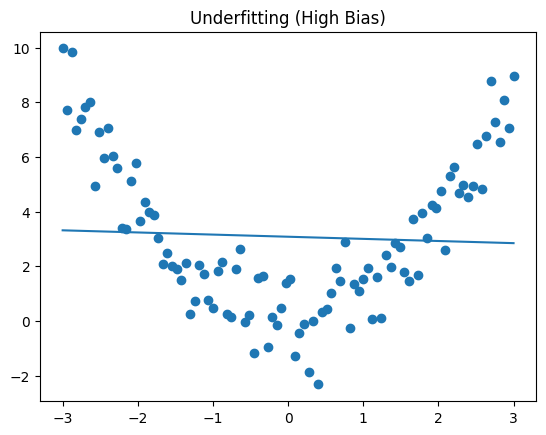

In [1]:
# ============================================
# LEVEL 1: UNDERFITTING (TOO SIMPLE)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Non-linear data
X = np.linspace(-3, 3, 100).reshape(-1,1)
y = X**2 + np.random.randn(100,1)

# Linear model (too simple)
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Underfitting (High Bias)")
plt.show()


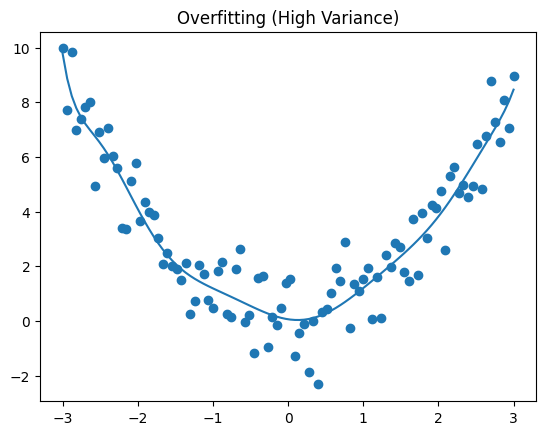

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Very complex model
model = make_pipeline(PolynomialFeatures(10), LinearRegression())
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Overfitting (High Variance)")
plt.show()

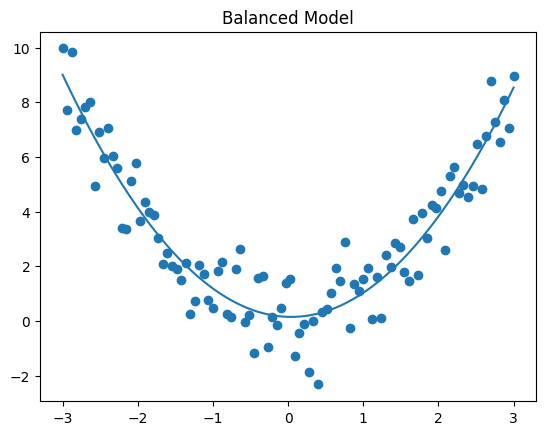

In [4]:
# Moderate complexity
model = make_pipeline(PolynomialFeatures(2), LinearRegression())
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Balanced Model")
plt.show()

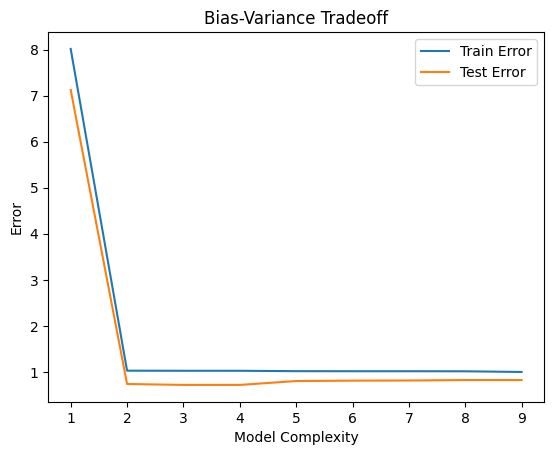

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

degrees = range(1, 10)

train_error = []
test_error = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_error.append(mean_squared_error(y_train, train_pred))
    test_error.append(mean_squared_error(y_test, test_pred))

plt.plot(degrees, train_error, label="Train Error")
plt.plot(degrees, test_error, label="Test Error")

plt.legend()
plt.title("Bias-Variance Tradeoff")
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.show()